# MNIST Autoencoder Basics

## Goal
The original notebook tried a simple Keras autoencoder on MNIST digits. I kept that same reconstruction idea, but rebuilt it into a clean fundamentals notebook that can be rerun directly from this repo.

## Data
This notebook uses the bundled `data/mnist.pkl.gz` file. Each image is a `28 x 28` grayscale digit, and the learning task is to compress the pixel grid into a smaller hidden representation and then reconstruct it.

## Limits
To keep runtime reasonable, I train on a subset of MNIST and use a small single-hidden-layer autoencoder. That is enough to show the bottleneck idea clearly without turning this into a long training run.


In [1]:
import gzip
import pickle
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)


## Load And Inspect The Digits
The source notebook already used MNIST, so I kept that dataset and only cleaned the path handling. The pickle stores the digits as full image arrays, which I flatten before training the autoencoder.


In [2]:
data_path = Path('data/mnist.pkl.gz')

with gzip.open(data_path, 'rb') as f:
    (x_train, y_train), (x_test, y_test) = pickle.load(f, encoding='bytes')

print('Raw train shape:', x_train.shape)
print('Raw test shape:', x_test.shape)
print('Pixel range before scaling:', float(x_train.min()), 'to', float(x_train.max()))

train_subset = 2500
test_subset = 800

X_train = x_train.reshape(len(x_train), -1).astype('float32') / 255.0
X_test = x_test.reshape(len(x_test), -1).astype('float32') / 255.0

y_train = y_train.astype(int)
y_test = y_test.astype(int)

X_train_small = X_train[:train_subset]
X_test_small = X_test[:test_subset]
y_test_small = y_test[:test_subset]

print('Training subset:', X_train_small.shape)
print('Test subset:', X_test_small.shape)
print('Scaled pixel range:', round(float(X_train_small.min()), 4), 'to', round(float(X_train_small.max()), 4))


Raw train shape: (60000, 28, 28)
Raw test shape: (10000, 28, 28)
Pixel range before scaling: 0.0 to 255.0
Training subset: (2500, 784)
Test subset: (800, 784)
Scaled pixel range: 0.0 to 1.0


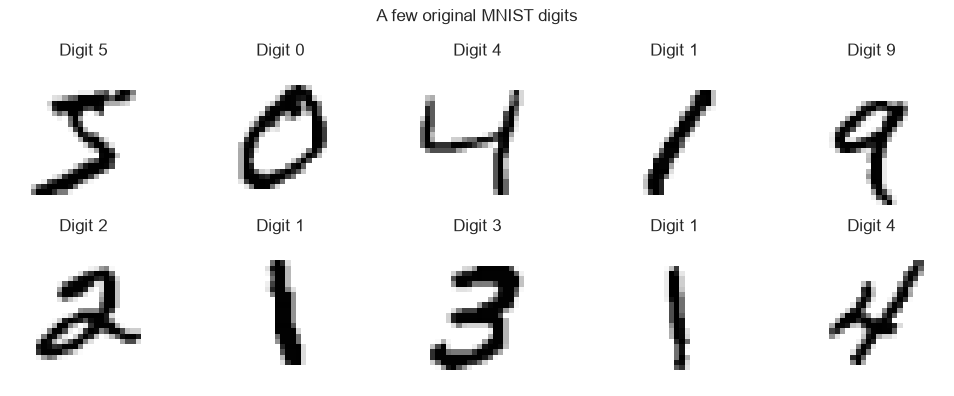

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), x_train[:10], y_train[:10]):
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'Digit {label}')
    ax.axis('off')
plt.suptitle('A few original MNIST digits')
plt.tight_layout()
plt.show()


## Model
I use a tiny autoencoder with a single `64`-unit hidden layer. In scikit-learn terms, that is just an `MLPRegressor` trained to predict the original pixel vector from itself.

That still captures the main autoencoder pattern:
- the encoder squeezes a 784-value image into a smaller hidden state
- the decoder expands that hidden state back to 784 pixel values


In [4]:
model = MLPRegressor(
    hidden_layer_sizes=(64,),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=128,
    learning_rate_init=1e-3,
    max_iter=30,
    early_stopping=True,
    n_iter_no_change=5,
    random_state=42,
)

start = time.perf_counter()
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=ConvergenceWarning)
    model.fit(X_train_small, X_train_small)
elapsed = time.perf_counter() - start

print('Hidden units:', model.hidden_layer_sizes[0])
print('Epochs used:', model.n_iter_)
print('Training time (seconds):', round(elapsed, 2))
print('Final training loss:', round(float(model.loss_), 6))
print('Best validation score:', round(float(model.best_validation_score_), 6))


Hidden units: 64
Epochs used: 30
Training time (seconds): 8.45
Final training loss: 0.006843
Best validation score: -0.015833


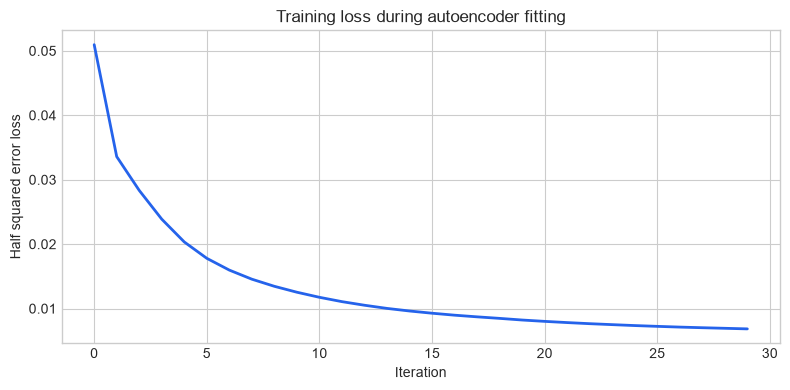

In [5]:
loss_curve = pd.Series(model.loss_curve_, name='loss')
ax = loss_curve.plot(figsize=(8, 4), color='#2563eb', linewidth=2)
ax.set_title('Training loss during autoencoder fitting')
ax.set_xlabel('Iteration')
ax.set_ylabel('Half squared error loss')
plt.tight_layout()
plt.show()


## Evaluation
A good reconstruction model should reproduce the main stroke pattern of each digit even after the bottleneck compression.


In [6]:
reconstructed = np.clip(model.predict(X_test_small), 0.0, 1.0)
reconstruction_mse = mean_squared_error(X_test_small, reconstructed)
reconstruction_mae = mean_absolute_error(X_test_small, reconstructed)

print('Test reconstruction MSE:', round(float(reconstruction_mse), 6))
print('Test reconstruction MAE:', round(float(reconstruction_mae), 6))


Test reconstruction MSE: 0.013545
Test reconstruction MAE: 0.055606


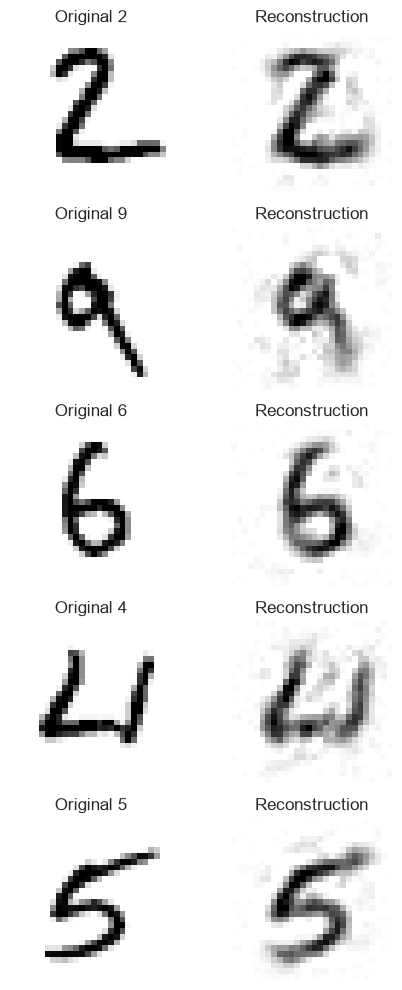

In [7]:
sample_indices = [1, 7, 21, 33, 52]
fig, axes = plt.subplots(len(sample_indices), 2, figsize=(5, 10))
for row, idx in enumerate(sample_indices):
    axes[row, 0].imshow(X_test_small[idx].reshape(28, 28), cmap='gray_r')
    axes[row, 0].set_title(f'Original {y_test_small[idx]}')
    axes[row, 1].imshow(reconstructed[idx].reshape(28, 28), cmap='gray_r')
    axes[row, 1].set_title('Reconstruction')
    axes[row, 0].axis('off')
    axes[row, 1].axis('off')
plt.tight_layout()
plt.show()


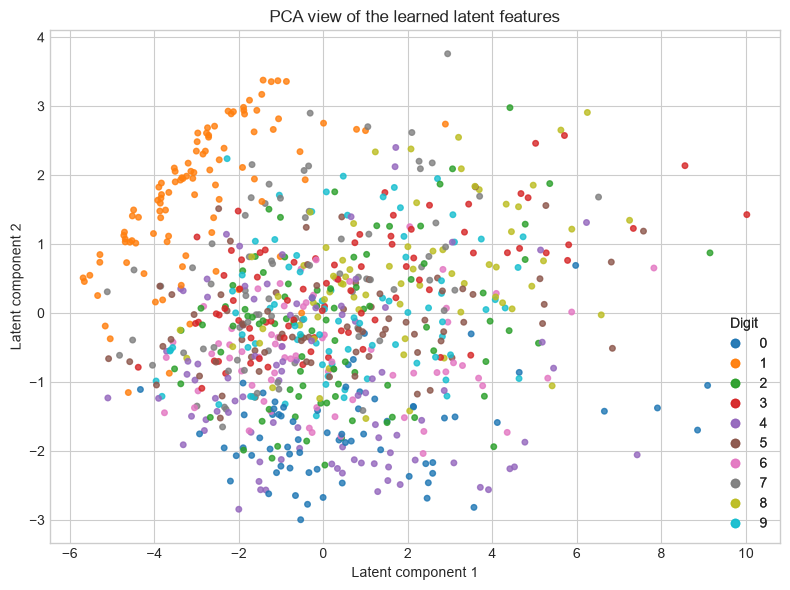

In [8]:
encoder_weights = model.coefs_[0]
encoder_bias = model.intercepts_[0]
latent = np.maximum(0.0, X_test_small @ encoder_weights + encoder_bias)
latent_2d = PCA(n_components=2, random_state=42).fit_transform(latent)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(latent_2d[:, 0], latent_2d[:, 1], c=y_test_small, cmap='tab10', s=16, alpha=0.8)
ax.set_title('PCA view of the learned latent features')
ax.set_xlabel('Latent component 1')
ax.set_ylabel('Latent component 2')
legend = ax.legend(*scatter.legend_elements(num=10), title='Digit', loc='best')
ax.add_artist(legend)
plt.tight_layout()
plt.show()


In [9]:
digit_mae = []
for digit in sorted(np.unique(y_test_small)):
    mask = y_test_small == digit
    digit_mae.append({
        'digit': digit,
        'count': int(mask.sum()),
        'mean_absolute_error': float(np.abs(X_test_small[mask] - reconstructed[mask]).mean()),
    })

pd.DataFrame(digit_mae).sort_values('mean_absolute_error').reset_index(drop=True)


,digit,count,mean_absolute_error
0,1,99,0.032849
1,7,78,0.050216
2,9,80,0.050391
3,4,92,0.055191
4,6,68,0.059365
5,0,70,0.061112
6,3,81,0.061445
7,5,75,0.061575
8,8,70,0.065081
9,2,87,0.065998


## What I Learned
- Even a small bottleneck layer can keep the overall digit structure while smoothing away some fine pixel detail.
- Reconstruction error is a simple way to judge whether the compressed representation still keeps the important information.
- Looking at the latent activations gives a better intuition for what the encoder is preserving than just watching the loss go down.

## Limits
This is still a small fundamentals example. A deeper TensorFlow autoencoder trained on the full dataset would usually produce sharper reconstructions and more expressive latent features.
